In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Generate Data

In [6]:
X_train = np.linspace(-1, 1, 20)
y_train = np.array(
    [
        -0.6561,
        -0.3099,
        -0.59035,
        -0.50855,
        -0.285,
        -0.2443,
        -0.02445,
        0.00135,
        -0.2006,
        0.07475,
        -0.1422,
        0.06515,
        0.15265,
        0.3521,
        0.28415,
        0.5524,
        0.23115,
        0.20835,
        0.4211,
        0.60485,
    ]
)

In [7]:
X_test = np.linspace(-1, 1, 20)
y_test = np.array(
    [
        -0.69415,
        -0.451,
        -0.43005,
        -0.4484,
        -0.1475,
        -0.5019,
        -0.28055,
        0.24595,
        -0.21425,
        -0.0286,
        0.23415,
        0.46575,
        0.07955,
        0.1973,
        0.0719,
        0.3639,
        0.5536,
        0.3365,
        0.50705,
        0.33435,
    ]
)

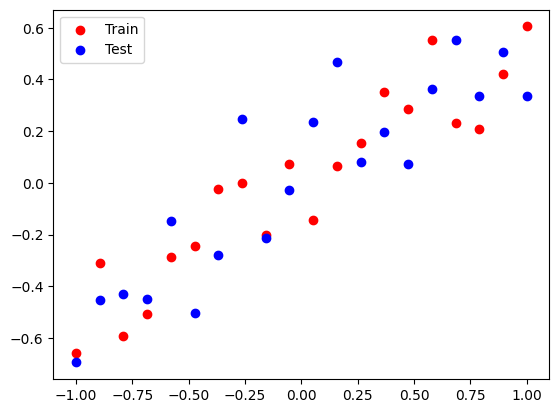

In [8]:
plt.scatter(X_train, y_train, c="red", label="Train")
plt.scatter(X_test, y_test, c="blue", label="Test")
plt.legend()
plt.show()

### Regression Model

In [ ]:
model = Sequential()

model.add(Dense(128, input_dim=1, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="linear"))

adam = Adam(learning_rate=0.01)
model.compile(loss="mse", metrics=["mse"], optimizer=adam)

history = model.fit(
    X_train, y_train, epochs=500, validation_data=(X_test, y_test), verbose="0"
)

In [10]:
_, train_mse = model.evaluate(X_train, y_train, verbose="0")
_, test_mse = model.evaluate(X_test, y_test, verbose="0")

print(f"Train: {train_mse}, Test: {test_mse}")

Train: 0.002033269964158535, Test: 0.045376598834991455


In [11]:
y_pred_1 = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


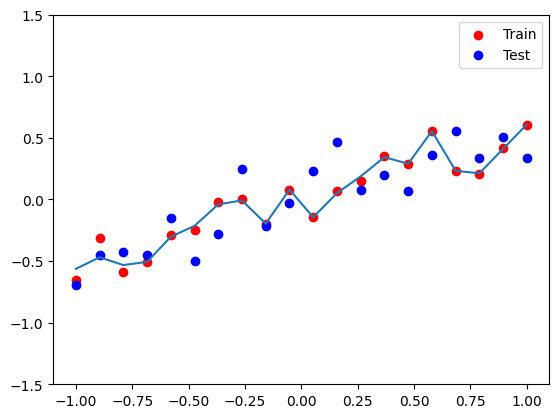

In [ ]:
plt.figure()
plt.scatter(X_train, y_train, c="red", label="Train")
plt.scatter(X_test, y_test, c="blue", label="Test")
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

- As we can see the model is overfitting to the training data
---
### Building a DropOut Model

In [ ]:
model = Sequential()

p = 0.5  # dropout ratio

model.add(Dense(128, input_dim=1, activation="relu"))
model.add(Dropout(p))
model.add(Dense(128, activation="relu"))
model.add(Dropout(p))
model.add(Dense(1, activation="linear"))

adam = Adam(learning_rate=0.01)
model.compile(loss="mse", metrics=["mse"], optimizer=adam)

history = model.fit(
    X_train, y_train, epochs=500, validation_data=(X_test, y_test), verbose=0
)

/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
_, train_mse = model.evaluate(X_train, y_train, verbose="0")
_, test_mse = model.evaluate(X_test, y_test, verbose="0")

print(f"Train: {train_mse}, Test: {test_mse}")

Train: 0.02090926095843315, Test: 0.04046164080500603


In [19]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


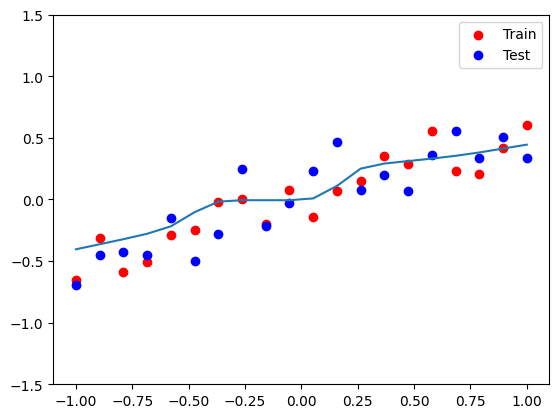

In [20]:
plt.figure()
plt.scatter(X_train, y_train, c="red", label="Train")
plt.scatter(X_test, y_test, c="blue", label="Test")
plt.plot(X_test, y_pred)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()